# Датасет k_VV и регрессия по температуре

1. **Датасет** — длинный формат: `T`, `i1`, `f1`, `i2`, `f2`, `k_VV` (см³/с, как в `k_vv_mm`). Имя файла: `{particle1}_{particle2}_dataset.csv`.
2. **Регрессия** — модель в логарифме: $\ln k(T) = \sum_{j=0}^{n-1} a_j\, T^{-j/3}$; для каждого перехода подбирается степень полинома с минимальной MAPE (как в `regression.ipynb`). Результат: `{particle1}_{particle2}_regression_coefs.csv` со столбцами `i1`, `f1`, `i2`, `f2`, `a_0`, …, `a_{n-1}` (недостающие коэффициенты — пустые ячейки).
3. **График** — сравнение «точного» `k_vv_mm` и значения по регрессии для выбранного перехода.

**Замечание.** Для регрессии нужна **сетка температур** (не одна точка). Ниже по умолчанию диапазон начинается с 300 K; при необходимости оставьте только `np.array([300.0])` для выгрузки датасета без подгонки.

Тетрадку следует запускать с рабочей папкой `FHO_FR_VV` (импорты `particles_data`, `k_vv_mm`).

Тетрадку следует запускать с рабочей папкой `FHO_FR_VV` (импорты `particles_data`, `k_vv_mm`).

In [1]:
from __future__ import annotations

import multiprocessing as mp
import os
import sys
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from particles_data import O2
from k_vv_mm import k_vv_mm

## Параметры

In [2]:
# Имена — только для имён файлов (объект O2 задаёт данные модели)
PARTICLE1_NAME = "O2"
PARTICLE2_NAME = "O2"

M1, M2 = O2, O2

# Максимальные колебательные уровни 0 … V_MAX включительно (как в R_VV / coeffs_sparse)
V_MAX = 6

# Сетка температур для датасета и регрессии [K]
TEMPERATURES_K = np.linspace(300.0, 6000.0, 10)

WORKDIR = Path(".")
DATASET_PATH = WORKDIR / f"{PARTICLE1_NAME}_{PARTICLE2_NAME}_dataset.csv"
# Переходы, которые вызывает k_lookup внутри R_VV_fast (все четыре ветки, v и v_ по 0…V_MAX)
DATASET_RVV_FAST_PATH = (
    WORKDIR / f"{PARTICLE1_NAME}_{PARTICLE2_NAME}_dataset_rvv_fast.csv"
)
COEFS_PATH = WORKDIR / f"{PARTICLE1_NAME}_{PARTICLE2_NAME}_regression_coefs.csv"

# Подбор степени полинома для ln k (число коэффицициентов = степень + 1)
POLY_TERM_COUNTS = range(4, 8)

# Параллельная генерация dataset_rvv_fast (процессы); None = все доступные ядра
RVV_FAST_WORKERS = os.cpu_count()

# Переход для визуальной проверки графика (начальное → конечное по молекулам 1 и 2)


## Генерация датасета

In [ ]:
# Датасет: переходы с i2=i1+1, f2=f1−1 при i1+1≤V_MAX, f1≥1, i1>f1 (длинный формат как в разделе ниже).
rows = []
t0 = time.time()
for T in TEMPERATURES_K:
    Tf = float(T)
    for i1 in range(V_MAX):
        for f1 in range(V_MAX):
            print(f"i1={i1} f1={f1}")
            if i1 + 1 <= V_MAX and f1 - 1 >= 0 and i1 > f1:
                i2, f2 = i1 + 1, f1 - 1
                print(f"T={T} i1={i1} f1={f1} i2={i2} f2={f2}")
                k = float(k_vv_mm(M1, M2, i1, f1, i2, f2, Tf))
                rows.append({"T": Tf, "i1": i1, "f1": f1, "i2": i2, "f2": f2, "k_VV": k})

df_dataset = pd.DataFrame(rows)
elapsed = time.time() - t0
n_tr = df_dataset.drop_duplicates(subset=["i1", "f1", "i2", "f2"]).shape[0]
print(f"Уникальных переходов: {n_tr}, строк: {len(df_dataset)}, время: {elapsed:.2f} s")
df_dataset.to_csv(DATASET_PATH, index=False)
print(f"Сохранено: {DATASET_PATH.resolve()}")
df_dataset.head()

### Датасет для `R_VV_fast`

Те же столбцы `T`, `i1`, `f1`, `i2`, `f2`, `k_VV`, но только для четырёх семейств вызовов `k_lookup` из `R_VV_fast` (`k1`…`k4`) при `v`, `v_` ∈ {0,…,`V_MAX`} и тех же `if`, что в модели. Файл: `DATASET_RVV_FAST_PATH`.

In [3]:
def transitions_for_r_vv_fast(v_max: int) -> set[tuple[int, int, int, int]]:
    """Уникальные (i1, f1, i2, f2), как в R_VV_fast при переборе v, v_ по 0…v_max."""
    out: set[tuple[int, int, int, int]] = set()
    for v in range(v_max + 1):
        for v_ in range(v_max + 1):
            if v + 1 <= v_max and v_ + 1 <= v_max:
                out.add((v_, v_ + 1, v + 1, v))
            if v - 1 >= 0 and v_ - 1 >= 0:
                out.add((v_, v_ - 1, v - 1, v))
            if v - 1 >= 0 and v_ + 1 <= v_max:
                out.add((v_, v_ + 1, v, v - 1))
            if v + 1 <= v_max and v_ - 1 >= 0:
                out.add((v_, v_ - 1, v, v + 1))
    return out


_M1_RVV = None
_M2_RVV = None


def _rvv_worker_init(m1, m2) -> None:
    global _M1_RVV, _M2_RVV
    _M1_RVV, _M2_RVV = m1, m2


def _compute_rvv_row(task: tuple[int, int, int, int, float]) -> dict:
    i1, f1, i2, f2, Tf = task
    from k_vv_mm import k_vv_mm

    k = float(k_vv_mm(_M1_RVV, _M2_RVV, i1, f1, i2, f2, Tf))
    return {"T": float(Tf), "i1": i1, "f1": f1, "i2": i2, "f2": f2, "k_VV": k}


quad_rvv = sorted(transitions_for_r_vv_fast(V_MAX))
tasks_rvv = [
    (i1, f1, i2, f2, float(T))
    for T in TEMPERATURES_K
    for i1, f1, i2, f2 in quad_rvv
]


def _rvv_executor(max_workers: int | None, m1, m2):
    exec_kw = {"initializer": _rvv_worker_init, "initargs": (m1, m2)}
    if sys.platform == "darwin" or sys.platform.startswith("linux"):
        try:
            ctx = mp.get_context("fork")
            return ProcessPoolExecutor(
                max_workers=max_workers, mp_context=ctx, **exec_kw
            )
        except ValueError:
            pass
    return ProcessPoolExecutor(max_workers=max_workers, **exec_kw)


t0_rvv = time.time()
rows_rvv: list[dict] = []
with _rvv_executor(RVV_FAST_WORKERS, M1, M2) as ex:
    fmap = {ex.submit(_compute_rvv_row, t): t for t in tasks_rvv}
    for fut in as_completed(fmap):
        row = fut.result()
        i1, f1, i2, f2 = row["i1"], row["f1"], row["i2"], row["f2"]
        print(
            f"готово: T={row['T']:.6g} K, i1={i1} f1={f1} i2={i2} f2={f2}, k_VV={row['k_VV']:.6g}",
            flush=True,
        )
        rows_rvv.append(row)

df_dataset_rvv_fast = pd.DataFrame(rows_rvv)
df_dataset_rvv_fast = df_dataset_rvv_fast.sort_values(
    ["T", "i1", "f1", "i2", "f2"], kind="mergesort"
).reset_index(drop=True)
elapsed_rvv = time.time() - t0_rvv
print(
    f"R_VV_fast: уникальных переходов {len(quad_rvv)}, строк {len(df_dataset_rvv_fast)}, "
    f"время {elapsed_rvv:.2f} s, workers={RVV_FAST_WORKERS!r}"
)
df_dataset_rvv_fast.to_csv(DATASET_RVV_FAST_PATH, index=False)
print(f"Сохранено: {DATASET_RVV_FAST_PATH.resolve()}")
df_dataset_rvv_fast.head()

готово: T=300 K, i1=1 f1=0 i2=2 f2=3, k_VV=6.87526e-14
готово: T=300 K, i1=0 f1=1 i2=2 f2=1, k_VV=4.96916e-14
готово: T=300 K, i1=1 f1=0 i2=0 f2=1, k_VV=2.53039e-14
готово: T=300 K, i1=1 f1=0 i2=1 f2=2, k_VV=4.96916e-14
готово: T=300 K, i1=0 f1=1 i2=4 f2=3, k_VV=8.01048e-14
готово: T=300 K, i1=1 f1=2 i2=2 f2=1, k_VV=1.04261e-13
готово: T=300 K, i1=1 f1=0 i2=4 f2=5, k_VV=8.37121e-14
готово: T=300 K, i1=0 f1=1 i2=1 f2=0, k_VV=2.53039e-14
готово: T=300 K, i1=1 f1=2 i2=1 f2=0, k_VV=4.96916e-14
готово: T=300 K, i1=1 f1=0 i2=3 f2=4, k_VV=8.01048e-14
готово: T=300 K, i1=0 f1=1 i2=5 f2=4, k_VV=8.37121e-14
готово: T=300 K, i1=0 f1=1 i2=3 f2=2, k_VV=6.87526e-14
готово: T=300 K, i1=1 f1=2 i2=6 f2=5, k_VV=2.07164e-13
готово: T=300 K, i1=0 f1=1 i2=6 f2=5, k_VV=8.1082e-14
готово: T=300 K, i1=1 f1=0 i2=5 f2=6, k_VV=8.1082e-14
готово: T=300 K, i1=1 f1=2 i2=4 f2=3, k_VV=1.88934e-13
готово: T=300 K, i1=1 f1=2 i2=3 f2=2, k_VV=1.53589e-13
готово: T=300 K, i1=1 f1=2 i2=5 f2=4, k_VV=2.06429e-13
готово: T=30

/Users/andrey/projects/fho_gen/FHO_FR_VV/k_vv_mm.py:66: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, _ = quad(integrand, 0, np.inf, args=args, epsabs=1e-15, epsrel=1e-15, limit=10000)


готово: T=6000 K, i1=5 f1=6 i2=6 f2=5, k_VV=4.66317e-11


/Users/andrey/projects/fho_gen/FHO_FR_VV/k_vv_mm.py:66: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, _ = quad(integrand, 0, np.inf, args=args, epsabs=1e-15, epsrel=1e-15, limit=10000)


готово: T=6000 K, i1=6 f1=5 i2=5 f2=6, k_VV=4.66317e-11
R_VV_fast: уникальных переходов 72, строк 720, время 1462.67 s, workers=18
Сохранено: /Users/andrey/projects/fho_gen/FHO_FR_VV/O2_O2_dataset_rvv_fast.csv


,T,i1,f1,i2,f2,k_VV
0,300.0,0,1,1,0,2.530386e-14
1,300.0,0,1,2,1,4.969157e-14
2,300.0,0,1,3,2,6.875261e-14
3,300.0,0,1,4,3,8.010478e-14
4,300.0,0,1,5,4,8.371205e-14


## Регрессия

In [4]:
def mape_loss(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100.0)


def k_model_poly(T, *coeffs):
    x = T ** (-1 / 3)
    return sum(c * x**k for k, c in enumerate(coeffs))


def k_predict_from_ln_poly(T_arr: np.ndarray, coeffs: np.ndarray) -> np.ndarray:
    T_arr = np.asarray(T_arr, dtype=float)
    return np.exp(k_model_poly(T_arr, *coeffs))


def fit_all_transitions(
    df: pd.DataFrame, poly_term_counts=POLY_TERM_COUNTS
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    df — длинный формат.
    Возвращает таблицу коэффициентов и wide-таблицу предсказанных k для MAPE-проверки.
    """
    df["transition"] = list(zip(df["i1"], df["f1"], df["i2"], df["f2"]))
    wide = df.pivot(index="T", columns="transition", values="k_VV")

    coeffs_rows = []
    pred_wide = pd.DataFrame(index=wide.index)

    T_col = wide.index.astype(float).values

    for col in wide.columns:
        y = wide[col].values.astype(float)

        best_mape = np.inf
        best_coeffs = None

        y_log = np.log(y)
        norm_factor = np.abs(y_log).max()
        y_norm = y_log / norm_factor

        for nc in poly_term_counts:
            params_norm, _ = curve_fit(
                k_model_poly,
                T_col,
                y_norm,
                p0=np.ones(nc),
                method="lm",
            )
            coeffs = params_norm * norm_factor
            k_pred = np.exp(k_model_poly(T_col, *coeffs))
            mm = mape_loss(y, k_pred)
            if mm < best_mape:
                best_mape = mm
                best_coeffs = coeffs

        assert best_coeffs is not None
        i1, f1, i2, f2 = col
        coeffs_rows.append(
            {"i1": i1, "f1": f1, "i2": i2, "f2": f2, "_mape": best_mape, "coeffs": best_coeffs}
        )
        pred_wide[col] = k_predict_from_ln_poly(T_col, best_coeffs)

    coeff_len = max(len(r["coeffs"]) for r in coeffs_rows)
    out = pd.DataFrame(
        [
            {
                "i1": r["i1"],
                "f1": r["f1"],
                "i2": r["i2"],
                "f2": r["f2"],
                **{f"a_{j}": r["coeffs"][j] if j < len(r["coeffs"]) else np.nan for j in range(coeff_len)},
            }
            for r in coeffs_rows
        ]
    )
    # Диагностический столбец (не входит в ваш список, но полезен; можно удалить перед экспортом)
    out.insert(5, "mape_pct", [r["_mape"] for r in coeffs_rows])
    return out, pred_wide


df_coeffs, df_pred_wide = fit_all_transitions(df_dataset_rvv_fast.copy())
df_coeffs.drop(columns=["mape_pct"]).to_csv(COEFS_PATH, index=False)
print(f"Сохранено: {COEFS_PATH.resolve()}")
df_coeffs.head()

Сохранено: /Users/andrey/projects/fho_gen/FHO_FR_VV/O2_O2_regression_coefs.csv


,i1,f1,i2,f2,a_0,mape_pct,a_1,a_2,a_3,a_4,a_5,a_6
0,0,1,1,0,-20.338013,0.000032,-232.072383,3082.376126,-30285.423394,191029.425467,-686929.532261,1.065774e+06
1,0,1,2,1,-19.952721,0.000004,-213.747940,2625.640604,-24052.142712,142399.836724,-484314.630436,7.156738e+05
2,0,1,3,2,-19.781039,0.000025,-199.691509,2276.986311,-19334.043646,105518.064120,-330950.723427,4.513912e+05
3,0,1,4,3,-19.690254,0.000044,-187.753597,1982.021641,-15377.405817,74427.805371,-201543.223306,2.288483e+05
4,0,1,5,4,-19.642034,0.000060,-177.059198,1718.308356,-11866.485438,46576.559494,-84765.722940,2.741392e+04


При необходимости сохраните версию **с** столбцом `mape_pct` для отбора плохих переходов.

In [5]:
df_coeffs_with_mape = df_coeffs.copy()
df_coeffs_with_mape.to_csv(
    WORKDIR / f"{PARTICLE1_NAME}_{PARTICLE2_NAME}_regression_coefs_with_mape.csv",
    index=False,
)

## График: точный k_VV и регрессия для выбранного перехода

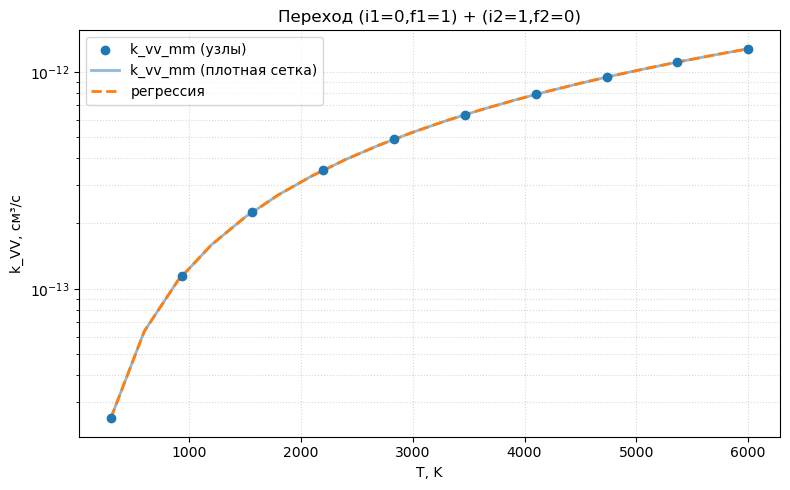

In [9]:
PLOT_TRANSITION = (0, 1, 1, 0)

def row_coeffs_for_transition(
    df_coef: pd.DataFrame, i1: int, f1: int, i2: int, f2: int
) -> np.ndarray:
    mask = (
        (df_coef["i1"] == i1)
        & (df_coef["f1"] == f1)
        & (df_coef["i2"] == i2)
        & (df_coef["f2"] == f2)
    )
    if not mask.any():
        raise KeyError((i1, f1, i2, f2))
    row = df_coef.loc[mask].iloc[0]
    a_cols = [c for c in df_coef.columns if c.startswith("a_")]
    vals = [row[c] for c in sorted(a_cols, key=lambda s: int(s.split("_")[1]))]
    return np.array([v for v in vals if pd.notna(v)], dtype=float)


i1_p, f1_p, i2_p, f2_p = PLOT_TRANSITION

# Плотная сетка по T только для красивой кривой регрессии
T_fine = np.linspace(TEMPERATURES_K.min(), TEMPERATURES_K.max(), 20)


def _k_exact_fine_init(m1, m2, i1, f1, i2, f2) -> None:
    global _KM1, _KM2, _KI1, _KF1, _KI2, _KF2
    _KM1, _KM2 = m1, m2
    _KI1, _KF1, _KI2, _KF2 = i1, f1, i2, f2


def _k_exact_fine_one(Tf: float) -> float:
    from k_vv_mm import k_vv_mm

    return float(k_vv_mm(_KM1, _KM2, _KI1, _KF1, _KI2, _KF2, float(Tf)))


def _fine_k_executor(max_workers, m1, m2, i1, f1, i2, f2):
    exec_kw = {
        "initializer": _k_exact_fine_init,
        "initargs": (m1, m2, i1, f1, i2, f2),
    }
    if sys.platform == "darwin" or sys.platform.startswith("linux"):
        try:
            ctx = mp.get_context("fork")
            return ProcessPoolExecutor(
                max_workers=max_workers, mp_context=ctx, **exec_kw
            )
        except ValueError:
            pass
    return ProcessPoolExecutor(max_workers=max_workers, **exec_kw)


T_fine_list = [float(t) for t in T_fine]
with _fine_k_executor(RVV_FAST_WORKERS, M1, M2, i1_p, f1_p, i2_p, f2_p) as ex:
    k_exact_fine = np.array(list(ex.map(_k_exact_fine_one, T_fine_list)), dtype=float)

cfs = row_coeffs_for_transition(df_coeffs, i1_p, f1_p, i2_p, f2_p)
k_reg_fine = k_predict_from_ln_poly(T_fine, cfs)

# Точки сетки (исходный датасет)
msk = (
    (df_dataset_rvv_fast["i1"] == i1_p)
    & (df_dataset_rvv_fast["f1"] == f1_p)
    & (df_dataset_rvv_fast["i2"] == i2_p)
    & (df_dataset_rvv_fast["f2"] == f2_p)
)
dsub = df_dataset_rvv_fast.loc[msk].sort_values("T")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(dsub["T"], dsub["k_VV"], color="C0", s=36, label="k_vv_mm (узлы)", zorder=3)
ax.plot(T_fine, k_exact_fine, color="C0", alpha=0.5, lw=2, label="k_vv_mm (плотная сетка)")
ax.plot(T_fine, k_reg_fine, "--", color="C1", lw=2, label="регрессия")
ax.set_xlabel("T, K")
ax.set_ylabel("k_VV, см³/с")
ax.set_title(f"Переход (i1={i1_p},f1={f1_p}) + (i2={i2_p},f2={f2_p})")
ax.set_yscale("log")
ax.legend()
ax.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()